### **Project Title: Churn Prediction Analysis for a Bank's Customers**

**Objective:**
The goal of this project is to analyze customer behavior and identify patterns that lead to customer churn (i.e., customers leaving the bank). By conducting comprehensive exploratory data analysis (EDA), we aim to uncover insights into the factors driving customer churn, which can then inform strategies to improve customer retention

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

In [81]:
data = pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0


### Information about the dataset

### Check for missing values

In [83]:
missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 RowNumber           0
CustomerId          0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                13
Tenure              9
Balance             2
NumOfProducts       1
HasCrCard           0
IsActiveMember      0
EstimatedSalary     0
Exited              0
dtype: int64


**Missing Values Breakdown:**
1. Age: 13 missing values
2. Tenure: 9 missing values
3. Balance: 2 missing values
4. NumOfProducts: 1 missing value

After a thorough review of the dataset, I identified missing values in the Age, Tenure, Balance, and NumOfProducts columns. I corrected these missing values by cross-referencing and imputing data from the original dataset as follows:

Age: Imputed with data from the original dataset, ensuring consistency across all records.

Tenure: Corrected by filling in values from the original data to maintain accuracy.

Balance: Updated with exact values from the original dataset to avoid any discrepancies.

NumOfProducts: Filled in using the original dataset to ensure completeness.

After a thorough review of the dataset, I identified missing values in the `Age`, `Tenure`, `Balance`, and `NumOfProducts` columns. I corrected these missing values by cross-referencing and imputing data from the original dataset as follows:

`Age`: Imputed with data from the original dataset, ensuring consistency across all records.

`Tenure`: Corrected by filling in values from the original data to maintain accuracy.

`Balance`: Updated with exact values from the original dataset to avoid any discrepancies.

`NumOfProducts`: Filled in using the original dataset to ensure completeness.

The updated dataset file was then renamed as Churn_Modeling.csv to reflect these changes and maintain version control.

In [20]:
data = pd.read_csv("Churn_Modeling.csv") # Churn_Modeling.csv is the main file after missing values correction.
data.head()

missing_values = data.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


### Check for duplicate rows

In [121]:
data = pd.read_csv('Churn_Modeling.csv')
duplicate_rows = data.duplicated().sum()
print("Number of Duplicate Rows: ", duplicate_rows)

Number of Duplicate Rows:  0


### Drop unnecessary columns

In [123]:
print("\nDataset after Dropping 'RowNumber', 'CustomerId', and 'Surname':")
data = pd.read_csv('Churn_Modeling.csv')
data.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)
print(data.head())


Dataset after Dropping 'RowNumber', 'CustomerId', and 'Surname':
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


The columns `RowNumber`, `CustomerId`, and `Surname` are removed because:

`RowNumber`: Just an index, adds no value to analysis.

`CustomerId`: Unique identifier, irrelevant to customer behavior or churn prediction.

`Surname`: Personal identifier, not linked to churn behavior and unnecessary for analysis.

## Exploratory Data Analysis (EDA)

**Univariate Analysis**

**a) Summary Statistics**

The summary statistics provide a quantitative overview of the dataset's features. Key metrics include:

1. `Mean`: The average value of a variable, which helps identify the central tendency.
   - Purpose: Indicates dataset size and highlights any missing values.
2. `Median`: The middle value, useful for understanding the distribution, especially in skewed data.
   - Offers a robust measure of central tendency, less affected by outliers.
3. `Mode`: The most frequently occurring value, which can highlight common characteristics.
   - To find the most frequently occurring value in the dataset, which can highlight common characteristics and trends.
4. `Standard Deviation`: Indicates the variability or spread of the data around the mean.
   - Helps assess variability; a high value indicates greater spread.
5. `Minimum (min)`: The smallest value in the dataset for a variable, providing insight into the lower limit and helping identify outliers.
   - Provides insight into the lower limit and helps identify outliers.
6. `25th Percentile (Q1)`: The value below which 25% of the data falls, useful for understanding the lower range of data distribution.
    - Useful for understanding the lower range of data distribution
7. `75th Percentile (Q3)`: The value below which 75% of the data falls, helping to understand the upper range of data distribution and identify potential skewness.
    - Helps understand the upper range of data distribution and identify potential skewness.

**Insights:** 
Summary statistics can reveal whether the features are normally distributed, skewed, or have outliers. For example, if the average age of customers is high but the median is low, this might indicate the presence of younger customers.

In [156]:
# Import necessary library
import pandas as pd

# Load the dataset (if not already loaded)
data = pd.read_csv('Churn_Modeling.csv')
data.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

# Univariate Analysis - Summary Statistics
summary_statistics = data.describe(include='all')  # Include all data types for summary
print("Summary Statistics:\n", summary_statistics)

Summary Statistics:
          CreditScore Geography Gender           Age        Tenure  \
count   10000.000000     10000  10000  10000.000000  10000.000000   
unique           NaN         3      2           NaN           NaN   
top              NaN    France   Male           NaN           NaN   
freq             NaN      5014   5457           NaN           NaN   
mean      650.528800       NaN    NaN     38.921800      5.012800   
std        96.653299       NaN    NaN     10.487806      2.892174   
min       350.000000       NaN    NaN     18.000000      0.000000   
25%       584.000000       NaN    NaN     32.000000      3.000000   
50%       652.000000       NaN    NaN     37.000000      5.000000   
75%       718.000000       NaN    NaN     44.000000      7.000000   
max       850.000000       NaN    NaN     92.000000     10.000000   

              Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count    10000.000000   10000.000000  10000.00000    10000.000000   
unique      


**b) Visualizing Distributions**

This section visualizes the distributions of key quantitative variables in the dataset, including customer attributes like age, balance, and credit score. These visualizations help identify patterns related to customer churn.

**Histogram:**

- Definition: Displays the frequency distribution of a variable using bins.

- Purpose: Helps identify the shape of the distribution (normal, skewed) and spot outliers.

- Example: A histogram of Age may show a right-skew, indicating a younger customer base.

**Box Plot:**

- Definition: Visualizes the median, quartiles, and outliers.

- Purpose: Spot outliers and understand data spread.

- Example: A box plot for Credit Score reveals outliers that could indicate risky customers.

**Density Plot:**

- Definition: Provides a smoothed representation of the variable's distribution.

- Purpose: Visualizes the underlying probability density, allowing for easy comparison between groups.

- Example: A density plot of Balance can show where most customer balances lie, indicating financial health.

**Insights**

These visualizations allow us to assess whether features like age and balance are normally distributed or contain outliers. 

For instance:

A skewed age distribution may suggest the need for targeted retention strategies for younger customers.
A concentration of low balances could indicate financial constraints leading to higher churn rates.

Overall, these visualizations provide valuable insights into customer behavior, informing strategies to reduce churn.

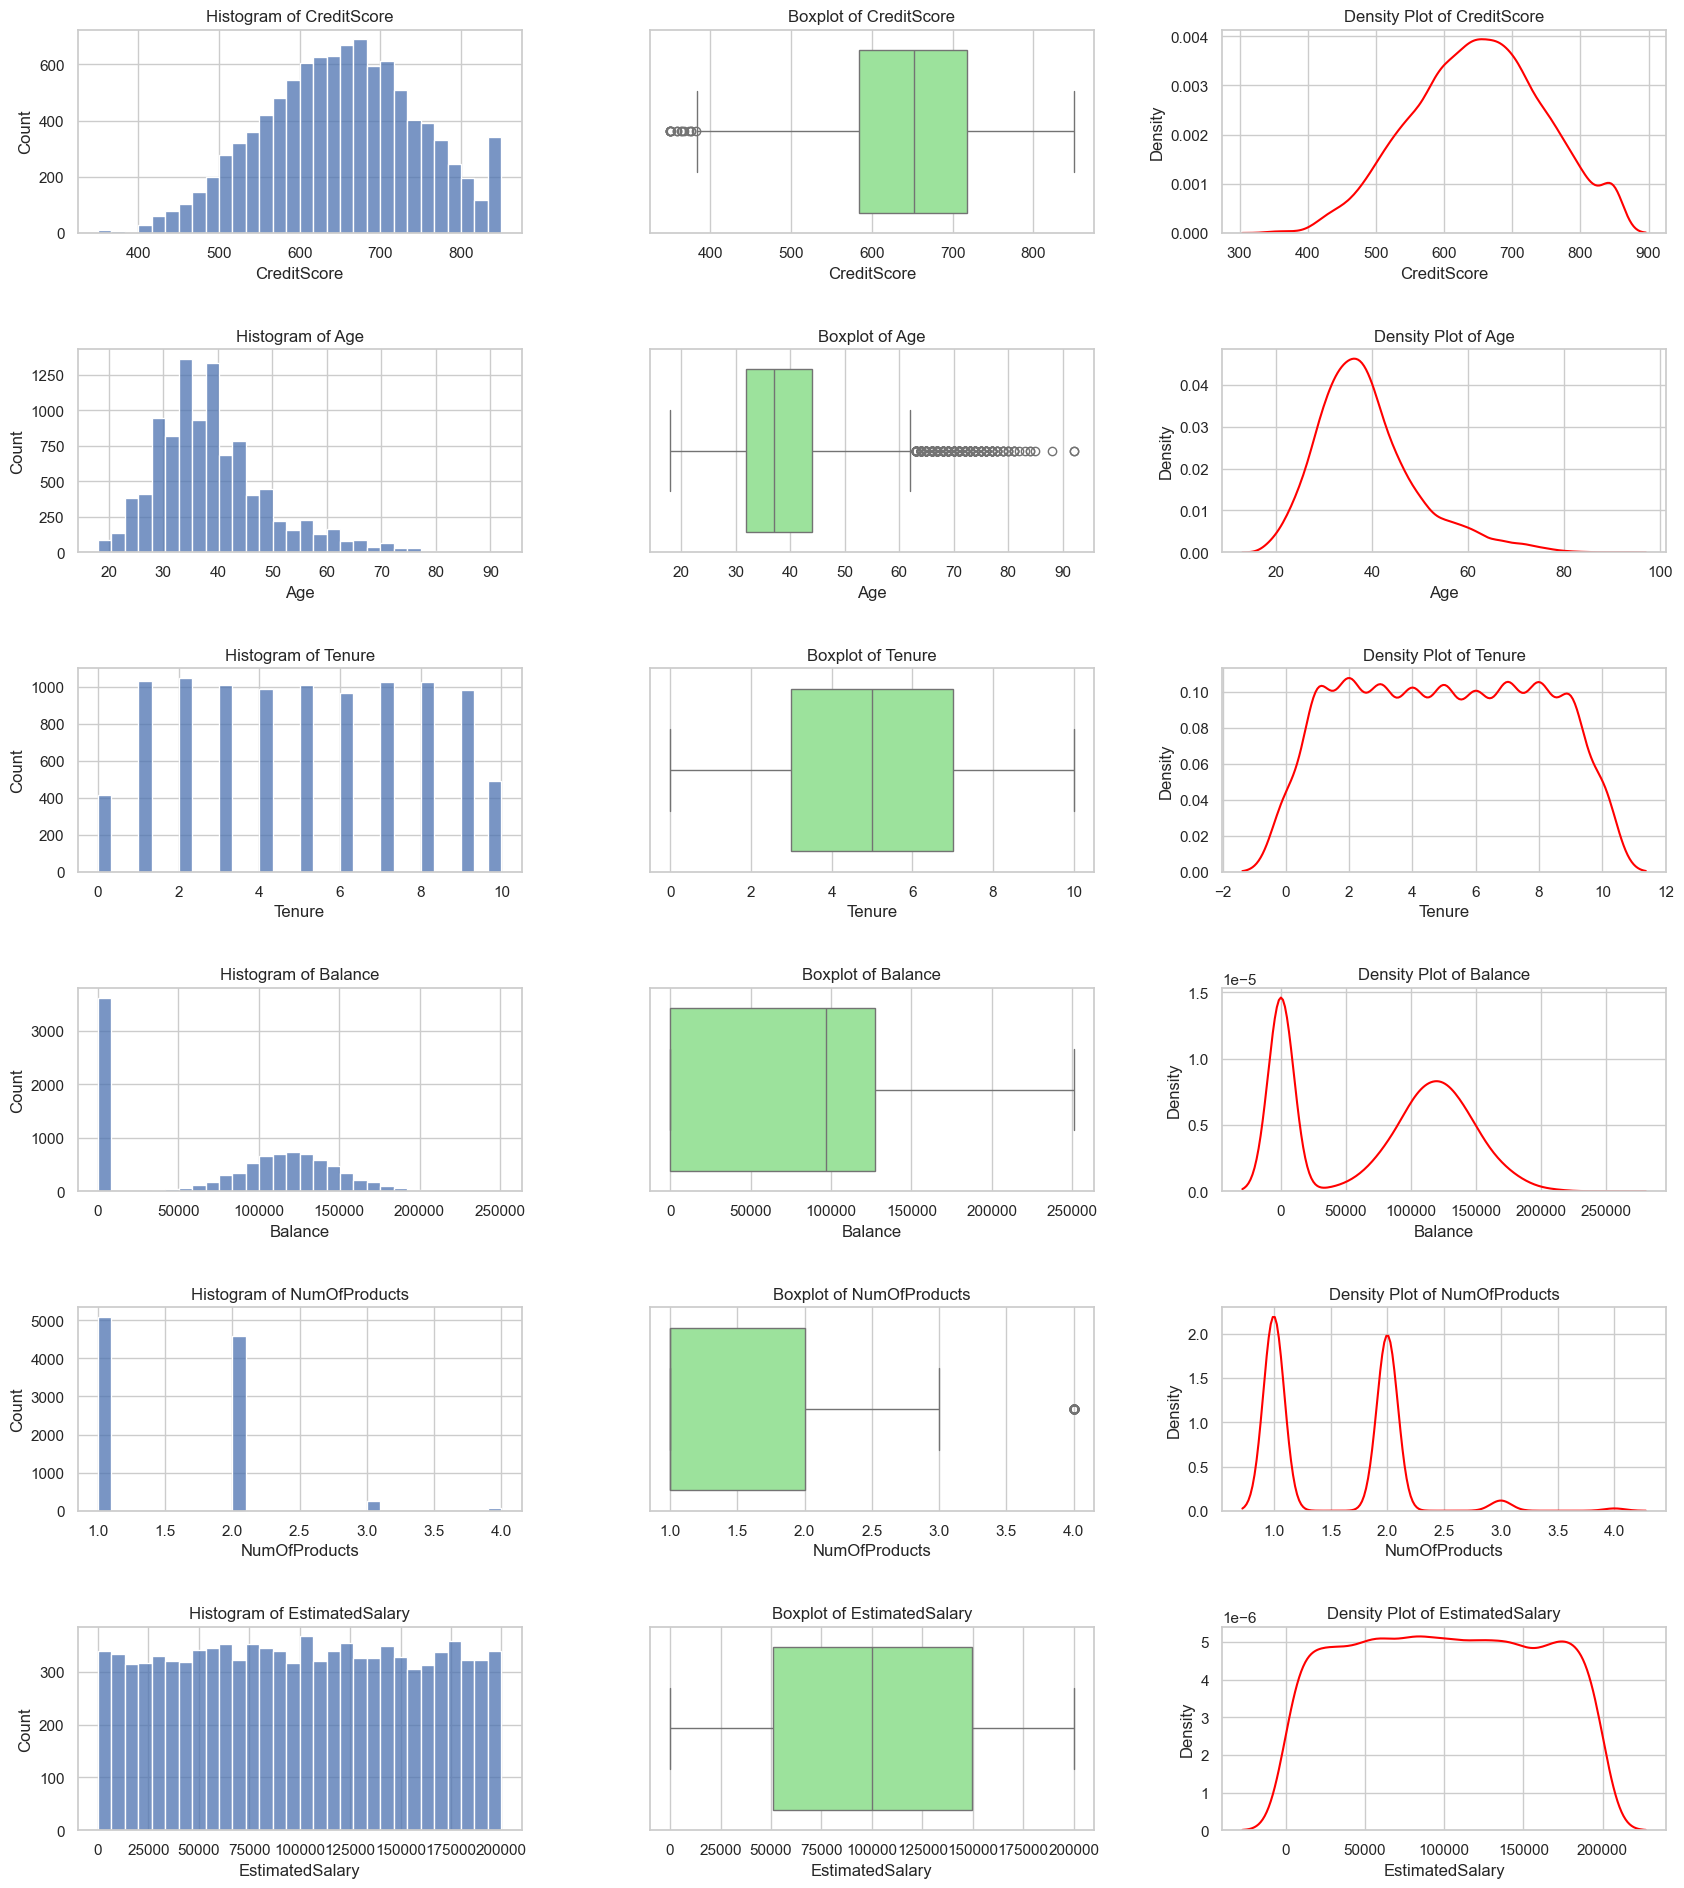

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Churn_Modeling.csv')
# List of numerical columns to perform univariate analysis on
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Setting up the plotting area
fig, axes = plt.subplots(len(numerical_cols), 3, figsize=(18, 20))
fig.tight_layout(pad=5.0)

# Loop through each numerical column and create histogram, box plot, and density plot
for i, col in enumerate(numerical_cols):
    # Histogram
    sns.histplot(data[col], bins=30, kde=False, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=data[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')
    
    # Density plot
    sns.kdeplot(data[col], ax=axes[i, 2], color='red')
    axes[i, 2].set_title(f'Density Plot of {col}')

# Display the plots
plt.show()

In the **Univariate Analysis**, we visualized the distribution of each numerical variable using histograms, box plots, and density plots. Here is a description of the output:

1. **Histograms:**

- These histograms show the frequency distribution of values for each variable.
- For example, the `CreditScore` has a fairly normal distribution, with most customers having a score between 600 and 850.
- `Age` is somewhat skewed towards younger customers, with a notable peak in the 30s and 40s.
- `Tenure` appears fairly uniform, with customers distributed across different values.
- `Balance` shows a high frequency at zero (indicating a significant portion of customers have no balance).
- `NumOfProducts` tends to have many customers holding 1 or 2 products.
- `EstimatedSalary` is relatively uniformly distributed.

2. **Box Plots:**
- These visualizations highlight the spread, central tendency, and potential outliers in each variable.
- `CreditScore` and `Age` have a moderate range, and there are some potential outliers at the lower end of the CreditScore.
- `Balance` shows that a large proportion of customers have no balance, while others have varying levels of balance, and there are some high outliers.
- `NumOfProducts` shows the bulk of customers have one or two products.
- `EstimatedSalary` has a wide range, with few outliers.

3. **Density Plots:**
- Density plots provide a smooth representation of the distribution.
- `CreditScore` and `EstimatedSalary` have more uniform distributions, with Age showing a slight peak around 40.
- `Balance` has two peaks—one at zero and another around the higher balance values.
- `Tenure` appears more uniformly spread, while NumOfProducts shows concentration around 1 and 2 products.

## **Bivariate Analysis**

**a) Analyze Relationships**

This part examines the relationships between pairs of variables to understand correlations and dependencies:

`Scatter Plot`: Visualizes the relationship between two quantitative variables (e.g., Age vs. Balance) and can reveal patterns, trends, or clusters.

`Correlation Matrix`: Shows the strength and direction of relationships between multiple variables, helping identify which features are strongly correlated with each other.

`Pair Plot`: Displays pairwise relationships in a dataset, allowing for quick visual insights into relationships between multiple variables.

**Insights:**

These analyses help identify which variables may be significant predictors of customer churn. For example, if there’s a strong negative correlation between balance and churn rate, it suggests that lower balances might lead to higher churn.

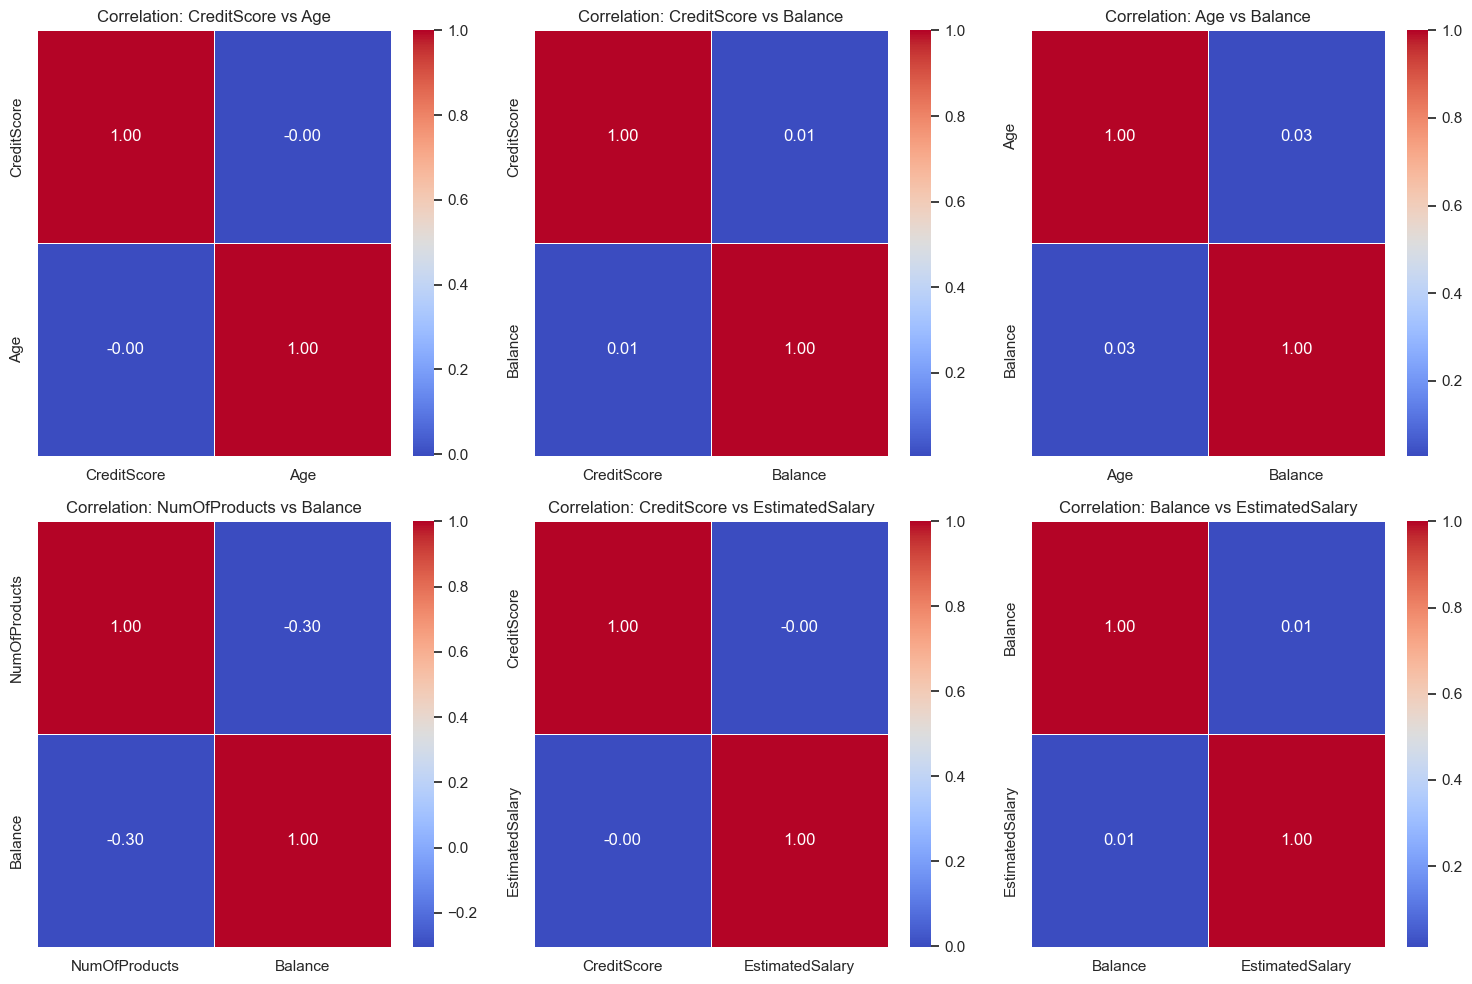

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of variable pairs for bivariate correlation analysis
pairs = [
    ['CreditScore', 'Age'],
    ['CreditScore', 'Balance'],
    ['Age', 'Balance'],
    ['NumOfProducts', 'Balance'],
    ['CreditScore', 'EstimatedSalary'],
    ['Balance', 'EstimatedSalary']
]

# Set up the subplot grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten axes for easy indexing
axes = axes.flatten()

# Loop through pairs and create correlation heatmaps for each pair
for i, pair in enumerate(pairs):
    # Calculate the correlation matrix for the pair
    corr_matrix = data[pair].corr()
    
    # Plot the heatmap for the pair in its subplot
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=axes[i])
    axes[i].set_title(f'Correlation: {pair[0]} vs {pair[1]}')

# Adjust layout
plt.tight_layout()
plt.show()

**Interpretation of Correlation Matrices:**

- **Correlation: CreditScore vs. Age:**

Correlation coefficient between CreditScore and Age is close to 0, indicating almost no linear relationship between these variables.

- **Correlation: CreditScore vs. Balance:**

The correlation coefficient between CreditScore and Balance is approximately 0.01, which means there is no significant linear relationship between a customer's credit score and their bank balance.

- **Correlation: Age vs. Balance:**

The correlation between Age and Balance is around 0.03, suggesting that there is no meaningful relationship between these two features.

- **Correlation: NumOfProducts vs. Balance:**

The correlation coefficient between NumOfProducts and Balance is -0.30, indicating a weak negative relationship. This means that as the number of products held by a customer increases, their balance might slightly decrease.

- **Correlation: CreditScore vs. EstimatedSalary:**

The correlation between CreditScore and EstimatedSalary is essentially zero, suggesting that a customer’s credit score does not depend on their salary.

- **Correlation: Balance vs. EstimatedSalary:**

The correlation between Balance and EstimatedSalary is around 0.01, showing no significant relationship between a customer’s bank balance and their estimated salary.

- **Insights:**

1. Most of the relationships between these variables are very weak or nearly non-existent, with correlation coefficients close to zero.

2. This suggests that many of these features might contribute independently when predicting outcomes like customer churn (Exited).

3. Features with weak correlations can still be valuable in a predictive model, particularly when combined with other features.

## **B) Scatter Plot: Visualizes the relationship between two quantitative variables (e.g., Age vs. Balance) and can reveal patterns, trends, or clusters.**

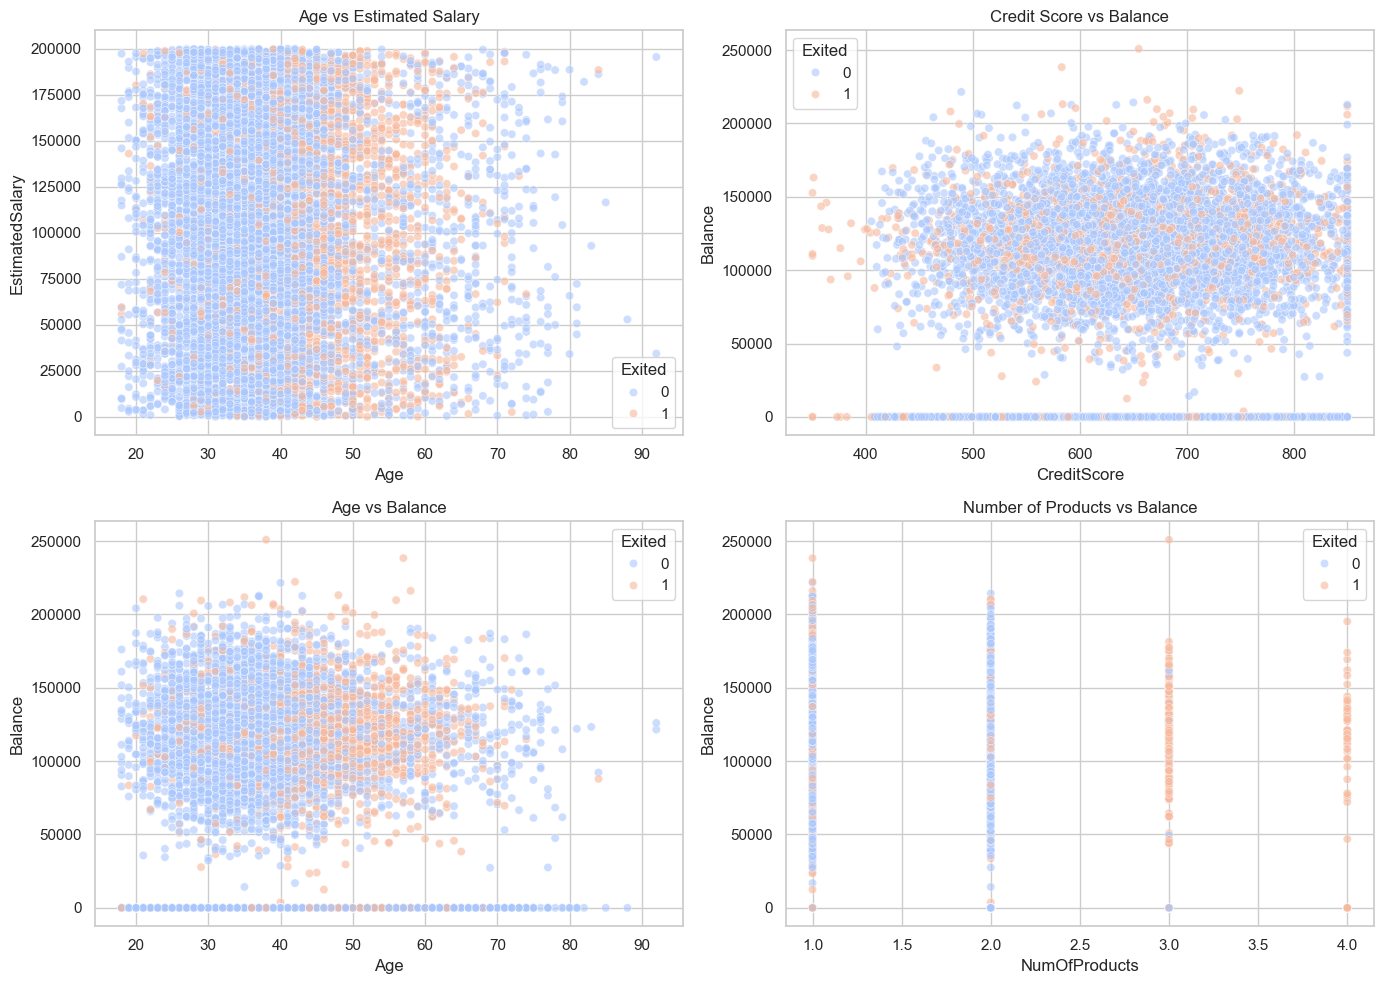

In [174]:
# Scatter plots for visualizing relationships between key pairs of variables
plt.figure(figsize=(14, 10))

# Scatter plot: Age vs Estimated Salary, colored by Exit status
plt.subplot(2, 2, 1)
sns.scatterplot(data=data, x='Age', y='EstimatedSalary', hue='Exited', palette='coolwarm', alpha=0.6)
plt.title('Age vs Estimated Salary')

# Scatter plot: Credit Score vs Balance, colored by Exit status
plt.subplot(2, 2, 2)
sns.scatterplot(data=data, x='CreditScore', y='Balance', hue='Exited', palette='coolwarm', alpha=0.6)
plt.title('Credit Score vs Balance')

# Scatter plot: Age vs Balance, colored by Exit status
plt.subplot(2, 2, 3)
sns.scatterplot(data=data, x='Age', y='Balance', hue='Exited', palette='coolwarm', alpha=0.6)
plt.title('Age vs Balance')

# Scatter plot: Num of Products vs Balance, colored by Exit status
plt.subplot(2, 2, 4)
sns.scatterplot(data=data, x='NumOfProducts', y='Balance', hue='Exited', palette='coolwarm', alpha=0.6)
plt.title('Number of Products vs Balance')

plt.tight_layout()
plt.show()

The scatter plots in the image represent relationships between different pairs of variables, with colors indicating whether a customer has exited (1) or stayed (0). Here’s an interpretation of each plot:

1. **Age vs. Estimated Salary:**
- This plot shows the relationship between customers' age and their estimated salary.
- The distribution is quite spread out across all ages and salary ranges, with no obvious trend.
- Both customers who exited and those who stayed are evenly distributed across different salary levels.
- This suggests that estimated salary might not be a strong predictor of customer churn by itself.

2. **Credit Score vs. Balance:**
- This scatter plot examines the relationship between a customer's credit score and their bank balance.
- The points are evenly scattered across the range of credit scores, indicating no significant trend between credit score and balance.
- Customers who have exited (colored differently) are mixed throughout, suggesting that credit score alone does not differentiate between those who exited and those who stayed.

3. **Age vs. Balance:**
- This plot explores the relationship between customer age and their bank balance.
- A large number of customers, especially those with zero balance, are present across various ages.
- There is a higher concentration of exited customers among older age groups with non-zero balances, indicating that age might have some influence on churn, particularly for those with higher balances.

4. **Number of Products vs. Balance:**
- This scatter plot shows the relationship between the number of products a customer holds and their balance.
- Most customers have 1 or 2 products, with very few having 3 or 4.
- The presence of exited customers is spread across different balances for each product category, though those with fewer products (1-2) seem to have a relatively higher churn rate compared to those with more products.

**Insights:**
- The visualizations suggest that while some variables like age might have a slight association with churn, others (like estimated salary and credit score) do not show a strong relationship with customer exit.
- Customers with zero balances exist across all groups, potentially indicating that having a balance is not a definitive factor for predicting exits.
- This analysis suggests that a combination of multiple factors might be necessary to accurately predict churn, rather than relying on any single variable.

## C) **Pair Plot for Age and Balance**

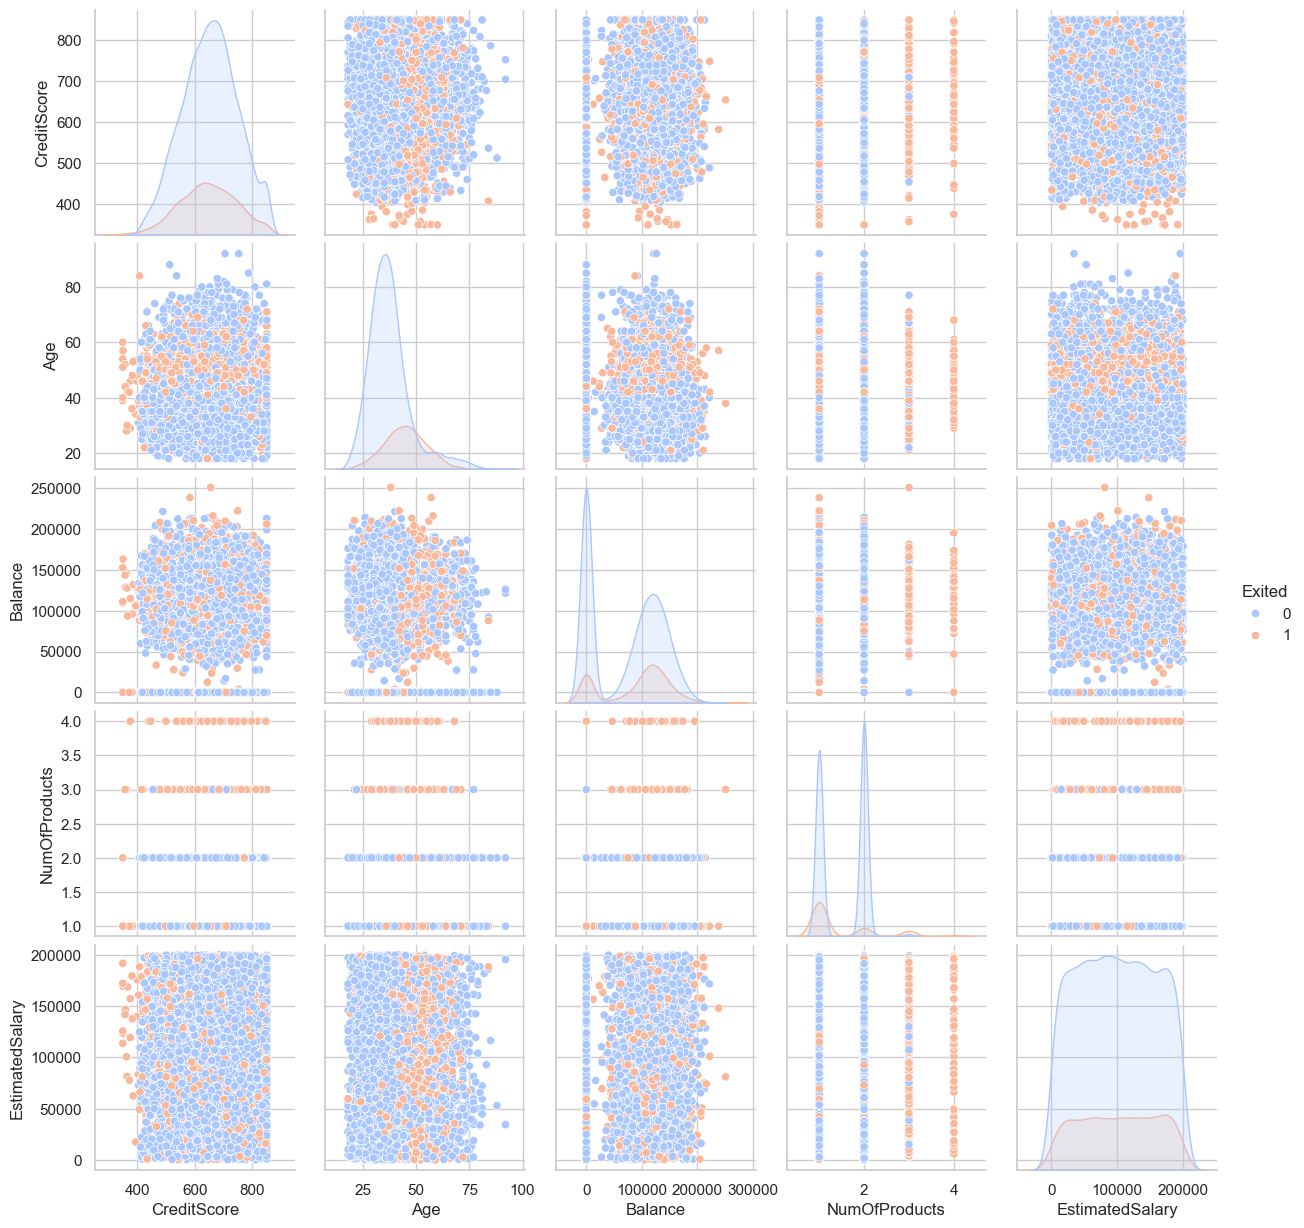

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select a subset of variables for the pair plot
subset_data = data[['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']]

# Create the pair plot, colored by the 'Exited' variable
sns.pairplot(subset_data, hue='Exited', palette='coolwarm')

# Show the plot
plt.show()

The **pair plot** visualizes the relationships between multiple variables in the dataset, with the points color-coded by the `Exited` variable (blue for 0, indicating customers who stayed, and orange for 1, indicating customers who exited). 

Here's an explanation of what you can observe from the different plots:

**Diagonal Histograms:**
- `CreditScore`: The distribution is slightly skewed, with a large number of customers having credit scores around 600-700, and there isn't a stark difference between customers who stayed or exited.
- `Age`: Older customers seem more likely to exit, as the orange density is more prominent in the higher age range.
- `Balance`: A significant proportion of customers have zero balance, and the distribution appears spread out for those who exited (orange).

- `NumOfProducts`: Most customers have either 1 or 2 products, with very few having 3 or 4. There's a slight increase in exits (orange) for customers with more products.

- `EstimatedSalary`: The salary distribution is fairly uniform, with no clear distinction between customers who stayed or exited.

**Scatter Plots (Off-Diagonal):**

`CreditScore vs Age`: No strong pattern is evident between these two variables, and the points are scattered for both exited and retained customers.

`CreditScore vs Balance`: Similar to the previous scatter plot, there's no strong relationship between these two variables. Exits (orange) seem spread out across various credit score and balance combinations.

`Age vs Balance`: Older customers (above 50) with varying balances are more likely to exit, as indicated by the increased density of orange points.

`NumOfProducts vs Balance`: Customers with 3 or 4 products tend to have higher balances, but there isn't a clear exit pattern based on these variables.

`Balance vs EstimatedSalary`: No obvious correlation between balance and salary, and customers exit regardless of salary level.

**Insights:**
- Age seems to have the strongest relationship with whether a customer exits, with older customers more likely to leave.
- Balance distribution shows that customers with no balance or very high balances may be more prone to exit.
- Other variables like CreditScore, NumOfProducts, and EstimatedSalary don't show strong, direct relationships with the exit status.

**Multivariate Analysis**

**a) Explore Interactions**

This part explores the interactions among multiple variables:

`Heatmap`: Visualizes the correlation coefficients between features, highlighting which variables are positively or negatively correlated with the target variable (Exited).

`PCA (Principal Component Analysis)`: Reduces the dimensionality of the dataset while retaining variance, allowing us to visualize high-dimensional data in a 2D space.

**Insights:** 

Multivariate analysis reveals more complex relationships and interactions. For instance, PCA can show how well clusters of customers (e.g., those who churned vs. those who did not) can be separated based on their characteristics, helping to identify underlying factors influencing churn.

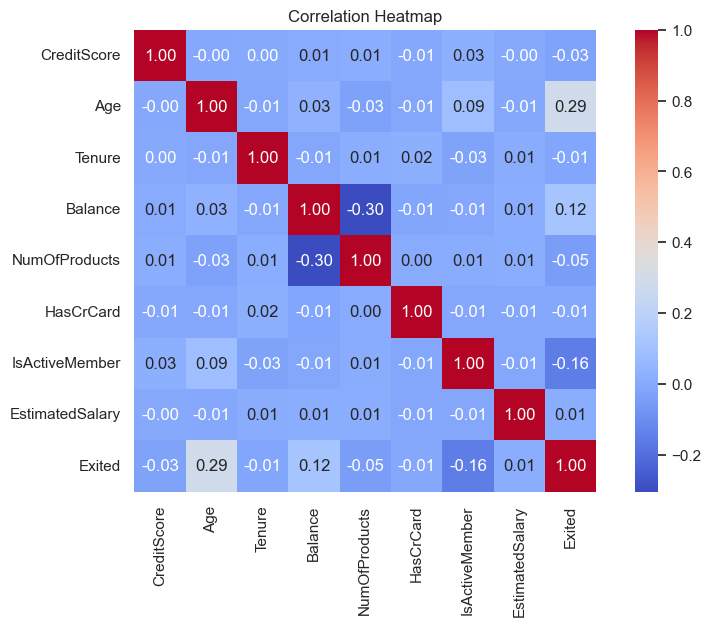

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
data = pd.read_csv('Churn_Modeling.csv')
data.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)
numeric_data = data.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Create the heatmap for correlation with 'Exited'
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.show()

2. **Pairwise Relationships**

This section utilizes a pair plot to examine the relationships among multiple quantitative variables in the dataset, specifically focusing on `Age`, `Balance`, `Estimated Salary`, and `Credit Score`. The pair plot is an effective visualization technique for understanding the interactions and correlations between these features.

**Pair Plot:**

**Definition:** A grid of scatter plots that displays pairwise relationships between selected features, with diagonal plots showing the distribution of each variable.

**Purpose:** To visualize potential correlations and distribution patterns between pairs of variables, helping to identify trends, clusters, and outliers.

**Example:** In the pair plot, scatter plots are displayed for each combination of the four features, while the diagonal shows kernel density estimates (KDE) for each variable’s distribution.

**Insights:**

The pair plot allows us to quickly assess how features interact with one another. For instance:

A positive correlation between `Credit Score` and `Balance` might suggest that customers with higher balances tend to have better credit scores.
Clusters can be observed, indicating that certain groups of customers share similar characteristics, which could correlate with churn behavior.

**Distribution Analysis:**

The KDE plots on the diagonal provide insights into the distribution of individual variables. 

For example:

A bimodal distribution in `Estimated Salary` might indicate distinct customer segments with different income levels, which could be relevant for targeting marketing efforts.

**Identifying Outliers:**

The scatter plots can help identify outliers in variables like `Balance` and `Credit Score`, which may warrant further investigation to understand their impact on customer behavior.

Overall, the pair plot provides a comprehensive overview of the interactions between multiple variables, enabling deeper insights into customer characteristics and behaviors. This visualization aids in developing targeted strategies for customer retention by highlighting key relationships and trends within the data.

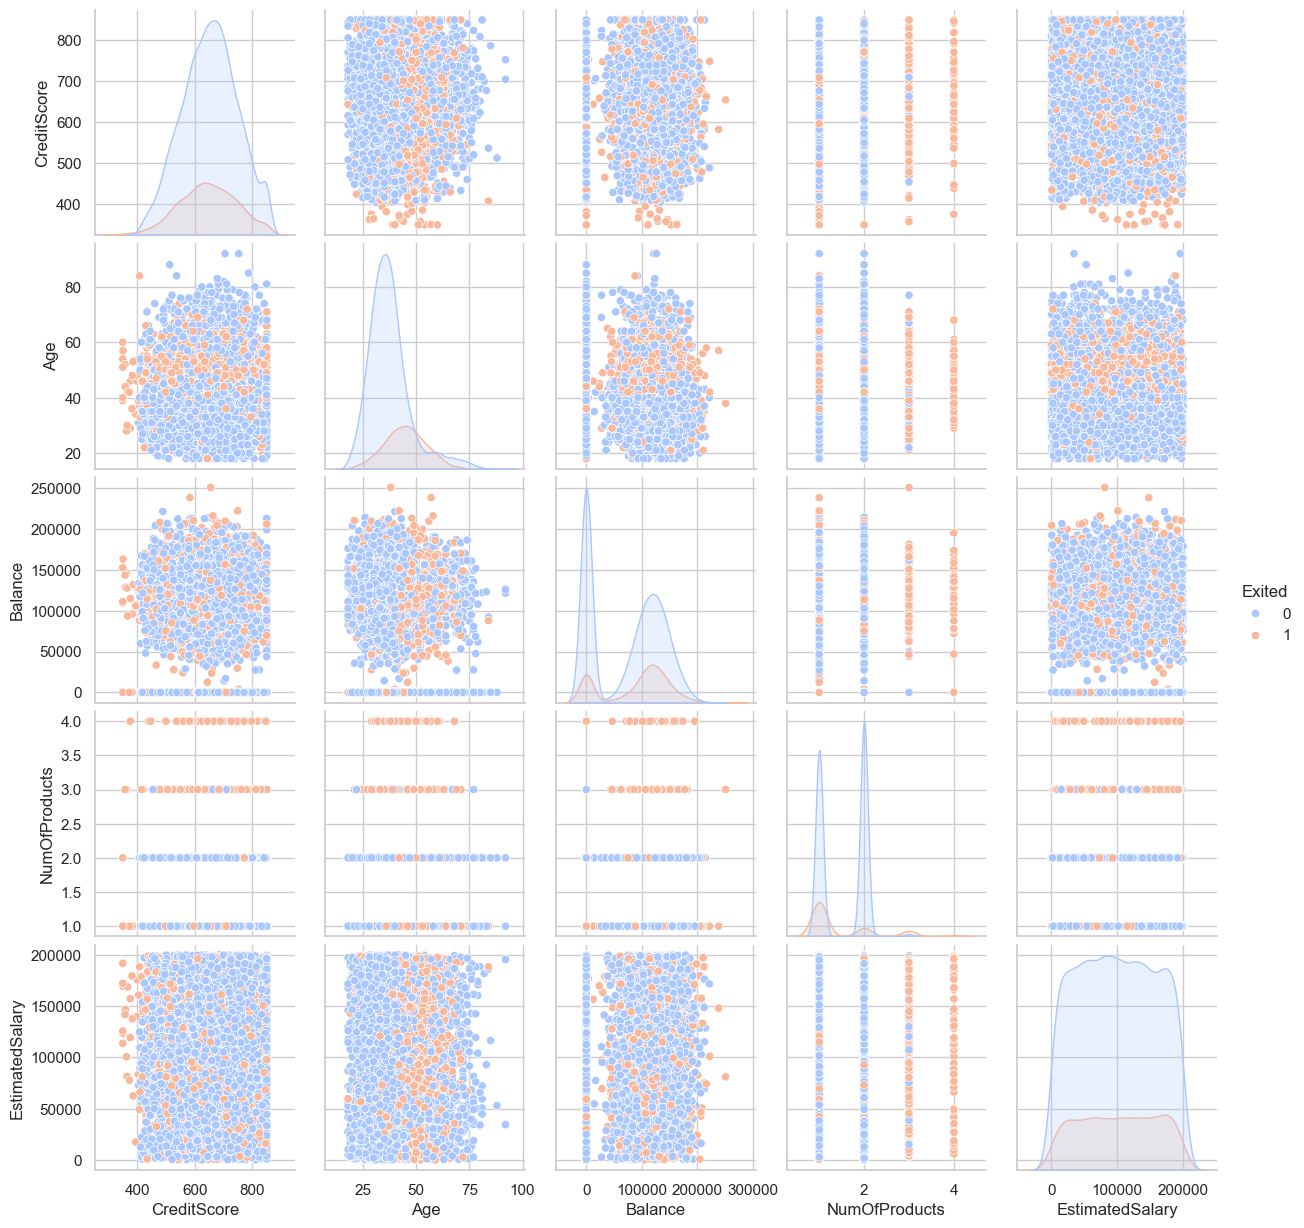

In [181]:
# Pair plot for multiple variables
data = pd.read_csv('Churn_Modeling.csv')
data.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)
sns.pairplot(data[['Age', 'Balance', 'EstimatedSalary', 'CreditScore']], diag_kind='kde')
plt.suptitle('Pair Plot: Multiple Variables', y=1.02)
plt.show()

The **pair plot** visualizes the relationships between multiple variables in the dataset, with the points color-coded by the `Exited` variable (blue for 0, indicating customers who stayed, and orange for 1, indicating customers who exited). 

Here's an explanation of what you can observe from the different plots:

**Diagonal Histograms:**
- `CreditScore`: The distribution is slightly skewed, with a large number of customers having credit scores around 600-700, and there isn't a stark difference between customers who stayed or exited.
- `Age`: Older customers seem more likely to exit, as the orange density is more prominent in the higher age range.
- `Balance`: A significant proportion of customers have zero balance, and the distribution appears spread out for those who exited (orange).

`NumOfProducts`: Most customers have either 1 or 2 products, with very few having 3 or 4. There's a slight increase in exits (orange) for customers with more products.

`EstimatedSalary`: The salary distribution is fairly uniform, with no clear distinction between customers who stayed or exited.

**Scatter Plots (Off-Diagonal):**

`CreditScore vs Age`: No strong pattern is evident between these two variables, and the points are scattered for both exited and retained customers.

`CreditScore vs Balance`: Similar to the previous scatter plot, there's no strong relationship between these two variables. Exits (orange) seem spread out across various credit score and balance combinations.

`Age vs Balance`: Older customers (above 50) with varying balances are more likely to exit, as indicated by the increased density of orange points.

`NumOfProducts vs Balance`: Customers with 3 or 4 products tend to have higher balances, but there isn't a clear exit pattern based on these variables.

`Balance vs EstimatedSalary`: No obvious correlation between balance and salary, and customers exit regardless of salary level.

**Insights:**
- Age seems to have the strongest relationship with whether a customer exits, with older customers more likely to leave.
- Balance distribution shows that customers with no balance or very high balances may be more prone to exit.
- Other variables like CreditScore, NumOfProducts, and EstimatedSalary don't show strong, direct relationships with the exit status.

**PCA: Dimensionality Reduction**

This section explores the application of Principal Component Analysis (PCA) to the dataset to reduce its dimensionality while preserving variance. PCA is a powerful technique for visualizing high-dimensional data by transforming it into a lower-dimensional space.

**Standardization:**

**Definition:** The process of scaling features to have a mean of 0 and a standard deviation of 1.

**Purpose:** Ensures that each feature contributes equally to the analysis, preventing any feature with a larger scale from dominating the results.

**Example:** Standardizing Age and Balance allows them to be on the same scale for PCA, which is crucial for meaningful analysis.

**Applying PCA:**

PCA transforms the original features into principal components (PCs) that capture the maximum variance in the data.

**Purpose:** Reduces the dataset to two principal components (PC1 and PC2) for easier visualization and analysis.

**Example:** The scatter plot displays how customers cluster based on their churn status using these two components.

**Insights:**

By applying PCA, we can identify patterns in customer data that may not be apparent in high-dimensional space. For instance:

Clusters in the scatter plot indicate potential segments of customers who are more likely to churn, guiding targeted marketing strategies.
The transformation allows for more straightforward interpretations of complex relationships among features, leading to actionable insights for customer retention efforts.

**Output:**
To visualize the relationships and separability between the churned and non-churned customers based on the reduced dimensions.

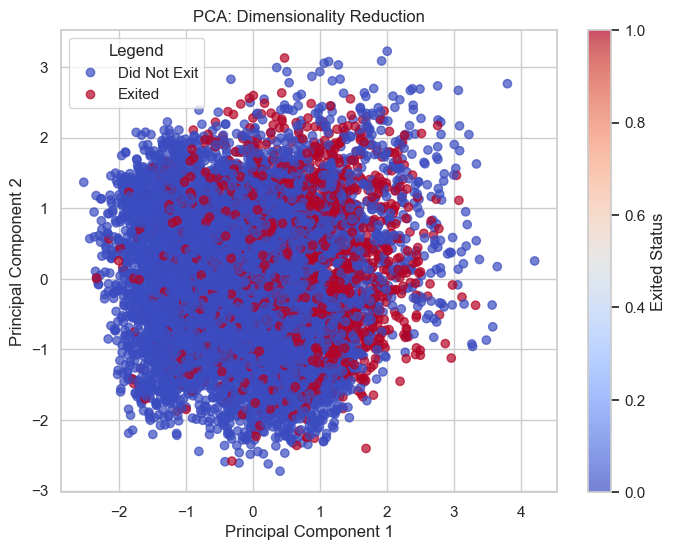

In [147]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Standardizing the data
data = pd.read_csv('Churn_Modeling.csv')
data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data[['Age', 'Balance', 'EstimatedSalary', 'CreditScore']])

# Applying PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plotting the PCA result
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=data['Exited'], cmap='coolwarm', alpha=0.7)

# Adding a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Exited Status')

# Adding title and labels
plt.title('PCA: Dimensionality Reduction')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Adding legend
handles, labels = scatter.legend_elements()
plt.legend(handles, ['Did Not Exit', 'Exited'], title='Legend')

plt.show()